In [1]:
import pandas as pd
import os


In [2]:
# 将json数据分模型存储至Excel

import pandas as pd
import os
folder = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4"
all_files = []
for root, dirs, files in os.walk(folder):
    for file in files:
        all_files.append(os.path.join(root, file))

# 数据输出
output_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    for file in all_files:
        # if file == '/Users/yanjieni/Desktop/脑脊液/naojiye/data/model_data/SVM_data1.json':
        #     continue
        # if file == '/Users/yanjieni/Desktop/脑脊液/naojiye/data/model_data/RF_data1.json':
        #     continue
        print(file)
        data = pd.read_json(file)
        result = []
        count = 0
        for dataset_name, comparisons in data.items():
            records = []
            
            for comparison_name, metrics in comparisons.items():
                # print(metrics)
                auc = round(metrics['roc_auc_test'],4)
                CI = (round(metrics['test_CI'][0],4),round(metrics['test_CI'][1],4))
                row = { "任务组": comparison_name, f"{dataset_name}": f'{auc} {CI}'}
                # row = {"数据集":dataset_name, "任务组": comparison_name}
                # print(metrics['roc_auc_test'])
                # row.update(metrics)
                records.append(row)
                # print(records)
                # # break
            if count == 0:
                results = records
                count += 1
            else:
                for record in records:
                    for result in results:
                        if result['任务组'] == record['任务组']:
                            result[list(record.keys())[1]] = record[list(record.keys())[1]]

        df = pd.DataFrame(results)
        model = (file.split('/')[-1]).split('_')[0]
        if (file.split('/')[-1]).split('_')[1] != 'data.json':
            model = model + '_' + (file.split('/')[-1]).split('_')[1]
        df = df.reindex(columns=['任务组',f'{model}_Dataset1',f'{model}_Dataset2',f'{model}_Dataset3',f'{model}_Dataset4',f'{model}_Dataset5',f'{model}_Dataset6',f'{model}_Dataset7',f'{model}_Dataset8',f'{model}_Dataset9']) 
        df.rename(columns={f'{model}_Dataset1': '血液37项+脑脊液19项', f'{model}_Dataset2': '血液203项+脑脊液19项', f'{model}_Dataset3': '血液37项', 
                           f'{model}_Dataset4': '血液203项', f'{model}_Dataset5': '脑脊液19项' ,f'{model}_Dataset6': '脑脊液8项',f'{model}_Dataset7': '血液37项+脑脊液8项', 
                           f'{model}_Dataset8': '血液203+脑脊液8',f'{model}_Dataset9': '精选特征集'}, inplace=True)
        
        sheet = ((file.split("/")[-1]).split(".")[0]).split("_")[0]
        if ((file.split("/")[-1]).split(".")[0]).split("_")[1] != 'data':
            sheet = sheet + '+' + ((file.split("/")[-1]).split(".")[0]).split("_")[1]
        # else:
        #     sheet = sheet + ((file.split("/")[-1]).split(".")[0]).split("_")[1]
        sheet_name = f"{sheet}模型结果"  
        df.to_excel(writer, sheet_name=sheet_name, index=False)

        print(f"已保存到 {output_file} 的 sheet: {sheet_name}")


/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_XGBoost2_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: LR+XGBoost2模型结果
/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/XGboost_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: XGboost模型结果
/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/MLP_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: MLP模型结果
/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_XGBoost5_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: LR+XGBoost5模型结果
/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/RF_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: RF模型结果
/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LightGBM_data.json
已保存到 /Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx 的 sheet: LightGBM模型结果
/Use

In [ ]:
# 生成单模型的最优模型结果

import pandas as pd

dfs = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx", sheet_name=None)

df = dfs['XGboost模型结果']

result1 = {}
row = df['任务组']

for i in (df.columns)[1:]:
    for j in range(len(row)):
        if i not in result1.keys():
            # result1[i] = {row[j]: f'{df[i][j]*100:.1f}%(XGboost)'}
            result1[i] = {row[j]: f'{df[i][j]*100:.1f}'}
        else:
            # result1[i][row[j]] = f'{df[i][j]*100:.1f}%(XGboost)'
            result1[i][row[j]] = f'{df[i][j]*100:.1f}'

print(result1)
for sheet, df in dfs.items():
    if sheet == '所有模型最优结果对比' or sheet == 'HMM模型结果' or sheet == 'LR+XGBoost1模型结果' or sheet == 'LR+XGBoost2模型结果' or sheet == 'LR+XGBoost3模型结果' :
        continue
    model = sheet[:-4]
    row = df['任务组']
    
    for i in (df.columns)[1:]:
        for j in range(len(row)):
            # compare1 = float(result1[i][row[j]].split("%")[0])
            compare1 = float(result1[i][row[j]])
            compare2 = float(f'{df[i][j]*100:.1f}')
            # print(compare1,compare2)
            if compare2 > compare1:
                # result1[i][row[j]] = f'{compare2}%({model})'
                result1[i][row[j]] = f'{compare2}'

# sheet_name = f"最优结果对比"  
# df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"已保存到 {output_file} 的 sheet: {sheet_name}")

df3 = pd.DataFrame(result1)
df3.index.name = '任务组'
df3 = df3.reset_index()
df3.to_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/单模型最优结果对比.xlsx", index=False)

In [ ]:
# 生成 单模型最优结果对比(带模型名称)

import pandas as pd

dfs = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx", sheet_name=None)

df = dfs['XGboost模型结果']

result1 = {}
row = df['任务组']

for i in (df.columns)[1:]:
    for j in range(len(row)):
        if i not in result1.keys():
            result1[i] = {row[j]: f'{df[i][j]*100:.1f}%(XGboost)'}
            # result1[i] = {row[j]: f'{df[i][j]*100:.1f}'}
        else:
            result1[i][row[j]] = f'{df[i][j]*100:.1f}%(XGboost)'
            # result1[i][row[j]] = f'{df[i][j]*100:.1f}'


for sheet, df in dfs.items():
    if sheet == '所有模型最优结果对比' or sheet == 'HMM模型结果' or sheet == 'LR+XGBoost1模型结果' or sheet == 'LR+XGBoost2模型结果' or sheet == 'LR+XGBoost3模型结果' :
        continue
    model = sheet[:-4]
    row = df['任务组']
    
    for i in (df.columns)[1:]:
        for j in range(len(row)):
            compare1 = float(result1[i][row[j]].split("%")[0])
            # compare1 = float(result1[i][row[j]])
            compare2 = float(f'{df[i][j]*100:.1f}')
            # print(compare1,compare2)
            if compare2 > compare1:
                result1[i][row[j]] = f'{compare2}%({model})'
                # result1[i][row[j]] = f'{compare2}'

# sheet_name = f"最优结果对比"  
# df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"已保存到 {output_file} 的 sheet: {sheet_name}")

df3 = pd.DataFrame(result1)
df3.index.name = '任务组'
df3 = df3.reset_index()
df3.to_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/单模型最优结果对比(带模型).xlsx", index=False)

In [ ]:
# 生成 全部模型最优结果对比

import pandas as pd

dfs = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx", sheet_name=None)

df = dfs['XGboost模型结果']

result1 = {}
row = df['任务组']

for i in (df.columns)[1:]:
    for j in range(len(row)):
        if i not in result1.keys():
            # result1[i] = {row[j]: f'{df[i][j]*100:.1f}%(XGboost)'}
            result1[i] = {row[j]: f'{df[i][j]*100:.1f}'}
        else:
            # result1[i][row[j]] = f'{df[i][j]*100:.1f}%(XGboost)'
            result1[i][row[j]] = f'{df[i][j]*100:.1f}'


for sheet, df in dfs.items():
    if sheet == '所有模型最优结果对比' or sheet == 'HMM模型结果':
        continue
    model = sheet[:-4]
    row = df['任务组']
    
    for i in (df.columns)[1:]:
        for j in range(len(row)):
            # compare1 = float(result1[i][row[j]].split("%")[0])
            compare1 = float(result1[i][row[j]])
            compare2 = float(f'{df[i][j]*100:.1f}')
            # print(compare1,compare2)
            if compare2 > compare1:
                # result1[i][row[j]] = f'{compare2}%({model})'
                result1[i][row[j]] = f'{compare2}'

# sheet_name = f"最优结果对比"  
# df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"已保存到 {output_file} 的 sheet: {sheet_name}")

df3 = pd.DataFrame(result1)
df3.index.name = '任务组'
df3 = df3.reset_index()
df3.to_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比.xlsx", index=False)

In [18]:
# 生成 全部模型最优结果对比

import pandas as pd

dfs = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果_CI.xlsx", sheet_name=None)

df = dfs['XGboost模型结果']

result1 = {}
row = df['任务组']

for i in (df.columns)[1:]:
    for j in range(len(row)):
        content = (df[i][j]).split(" ")
        if i not in result1.keys():
            # result1[i] = {row[j]: f'{df[i][j]*100:.1f}%(XGboost)'}
            result1[i] = {row[j]: f'{float(content[0])*100:.1f}%\n{content[1]} {content[2]}'}
        else:
            # result1[i][row[j]] = f'{df[i][j]*100:.1f}%(XGboost)'
            result1[i][row[j]] = f'{float(content[0])*100:.1f}%\n{content[1]} {content[2]}'


for sheet, df in dfs.items():
    if sheet == '所有模型最优结果对比' or sheet == 'HMM模型结果':
        continue
    model = sheet[:-4]
    row = df['任务组']
    
    for i in (df.columns)[1:]:
        for j in range(len(row)):
            content_1 = (result1[i][row[j]]).split("%")
            # print(df[i][j])
            content_2 = (df[i][j]).split(" ")
            # compare1 = float(result1[i][row[j]].split("%")[0])
            compare1 = float(content_1[0])
            compare2 = float(f'{float(content_2[0])*100:.1f}')
            # print(compare1,compare2)
            if compare2 > compare1:
                # result1[i][row[j]] = f'{compare2}%({model})'
                result1[i][row[j]] = f'{float(content_2[0])*100:.1f}%\n{content_2[1]} {content_2[2]}'

# sheet_name = f"最优结果对比"  
# df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"已保存到 {output_file} 的 sheet: {sheet_name}")

df3 = pd.DataFrame(result1)
df3.index.name = '任务组'
df3 = df3.reset_index()
df3.to_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比_CI.xlsx", index=False)

In [ ]:
# 生成 全部模型最优结果对比（带模型名称）

import pandas as pd

dfs = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx", sheet_name=None)

df = dfs['XGboost模型结果']

result1 = {}
row = df['任务组']

for i in (df.columns)[1:]:
    for j in range(len(row)):
        if i not in result1.keys():
            result1[i] = {row[j]: f'{df[i][j]*100:.1f}%(XGboost)'}
            # result1[i] = {row[j]: f'{df[i][j]*100:.1f}'}
        else:
            result1[i][row[j]] = f'{df[i][j]*100:.1f}%(XGboost)'
            # result1[i][row[j]] = f'{df[i][j]*100:.1f}'


for sheet, df in dfs.items():
    if sheet == '所有模型最优结果对比' or sheet == 'HMM模型结果':
        continue
    model = sheet[:-4]
    row = df['任务组']
    
    for i in (df.columns)[1:]:
        for j in range(len(row)):
            compare1 = float(result1[i][row[j]].split("%")[0])
            # compare1 = float(result1[i][row[j]])
            compare2 = float(f'{df[i][j]*100:.1f}')
            # print(compare1,compare2)
            if compare2 > compare1:
                result1[i][row[j]] = f'{compare2}%({model})'
                # result1[i][row[j]] = f'{compare2}'

# sheet_name = f"最优结果对比"  
# df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"已保存到 {output_file} 的 sheet: {sheet_name}")

df3 = pd.DataFrame(result1)
df3.index.name = '任务组'
df3 = df3.reset_index()
df3.to_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比（带模型）.xlsx", index=False)

旧版可视化图

matplotlib 识别的字体名: Songti SC


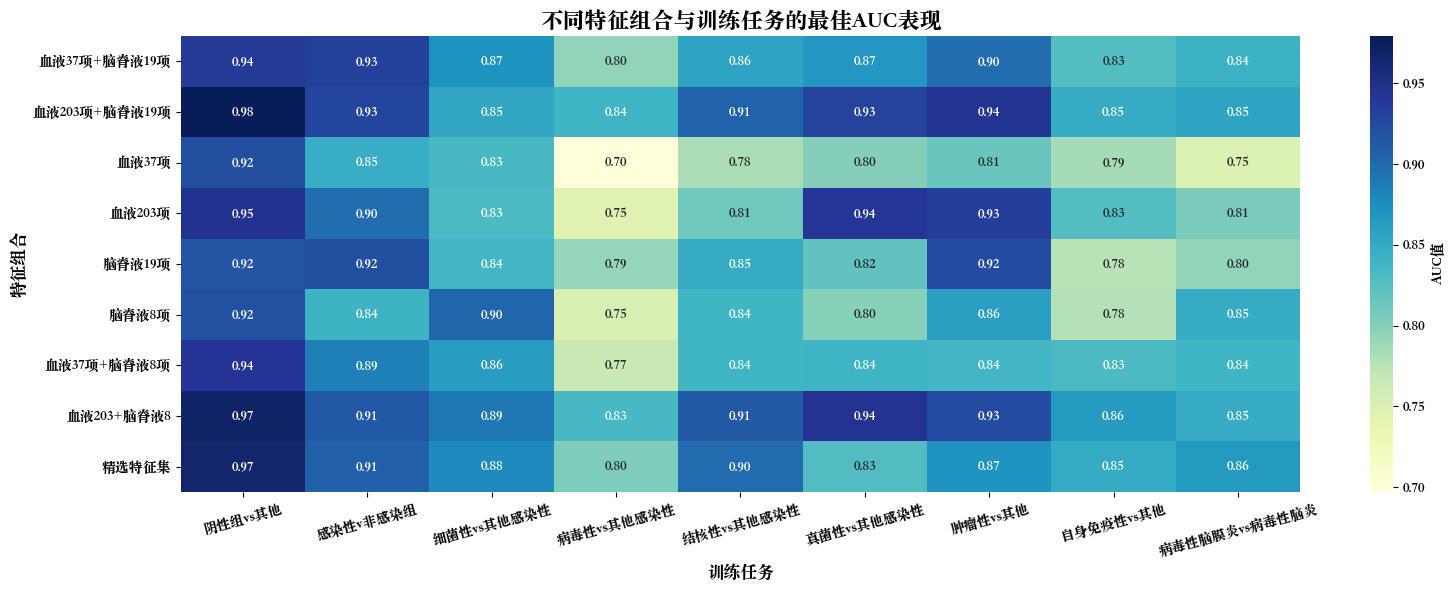

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import pandas as pd
# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


# df = pd.read_excel('/Users/yanjieni/Desktop/脑脊液/naojiye/最优结果对比2.xlsx',index_col='任务组').transpose()
df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比.xlsx',index_col='任务组')

# 设置画布大小
plt.figure(figsize=(16, 6))

# 绘制热力图
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'AUC值'})

# 标题和标签
plt.title("不同特征组合与训练任务的最佳AUC表现", fontsize=16)
plt.xlabel("训练任务", fontsize=12)
plt.ylabel("特征组合", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


matplotlib 识别的字体名: Songti SC


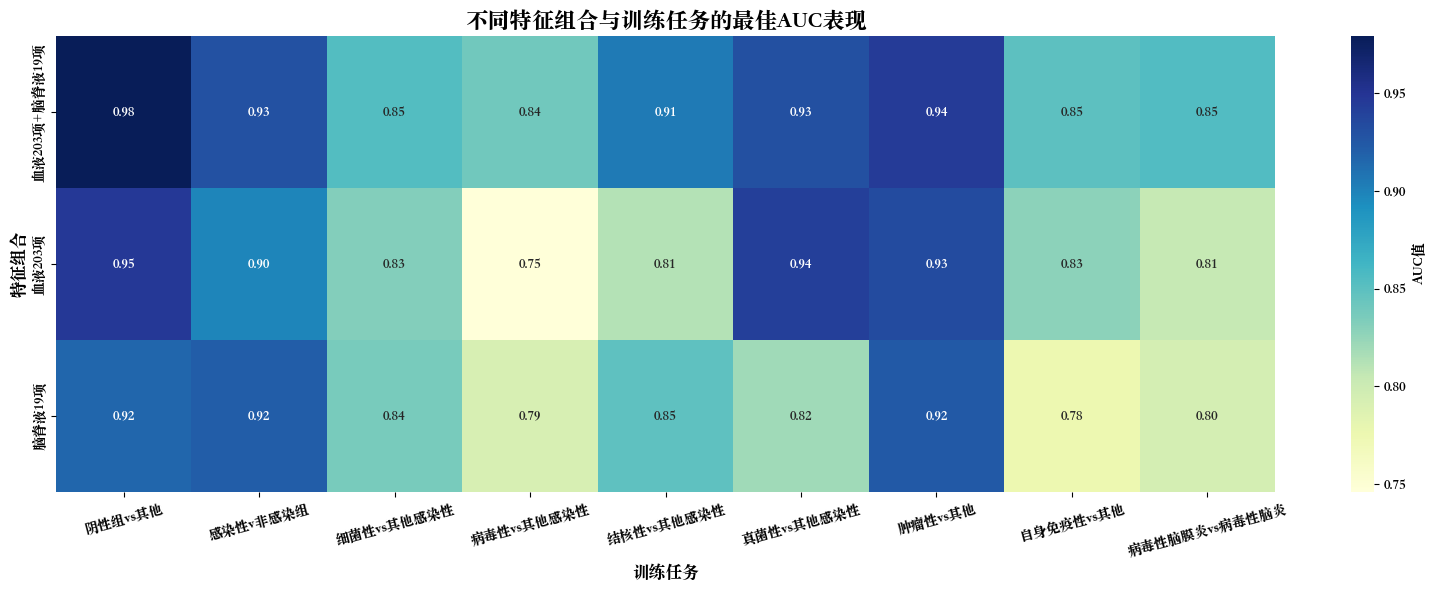

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import pandas as pd
# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


# df = pd.read_excel('/Users/yanjieni/Desktop/脑脊液/naojiye/最优结果对比2.xlsx',index_col='任务组').transpose()
df = pd.read_excel('/Users/yanjieni/Desktop/脑脊液/naojiye/脑脊液与血液特征对比.xlsx',index_col='任务组')

# 设置画布大小
plt.figure(figsize=(16, 6))

# 绘制热力图
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'AUC值'})

# 标题和标签
plt.title("不同特征组合与训练任务的最佳AUC表现", fontsize=16)
plt.xlabel("训练任务", fontsize=12)
plt.ylabel("特征组合", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


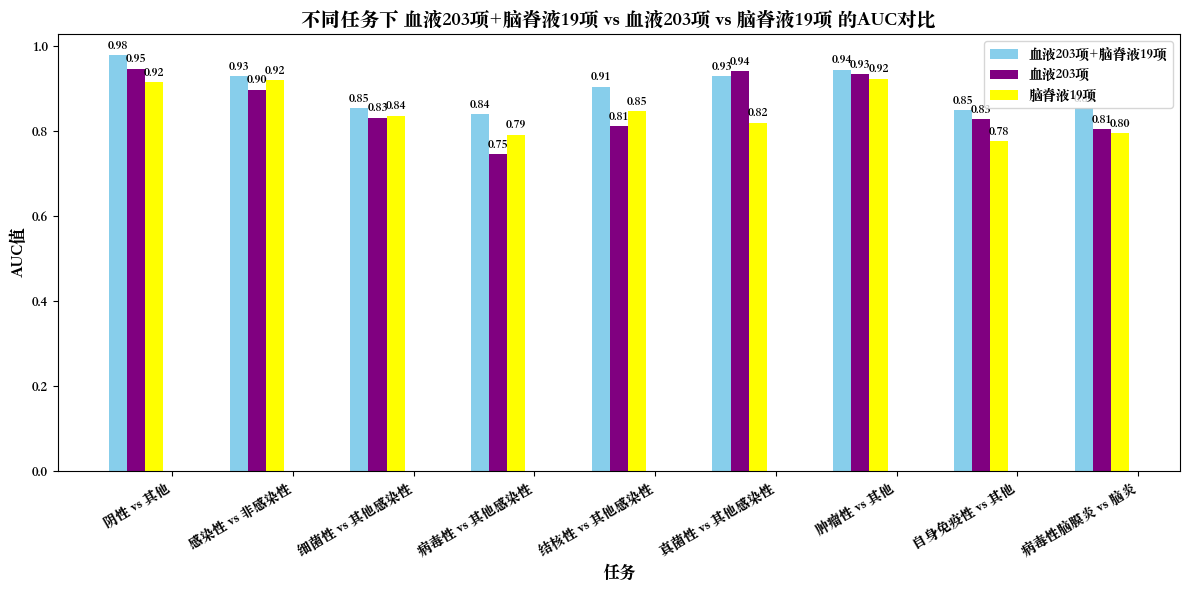

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
# df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

# singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/脑脊液与血液特征对比.xlsx", index_col='任务组')
model1 = list(df3['血液203项+脑脊液19项'])
model2 = list(df3['血液203项'])
model3 = list(df3['脑脊液19项'])
# singel_model2 = [round(x*100,2) for x in singel_model2]
# singel_model3 = [round(x*100,2) for x in singel_model3]
# mixed_model1 = [round(x*100,2) for x in mixed_model1]
# mixed_model2 = [round(x*100,2) for x in mixed_model2]
# mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],

    "血液203项+脑脊液19项": model1,
    "血液203项": model2,
    "脑脊液19项": model3
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.15  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width*3, df["血液203项+脑脊液19项"], width, label="血液203项+脑脊液19项", color="skyblue")
bars2 = ax.bar(x - width*2, df["血液203项"], width, label="血液203项", color="purple")
bars3 = ax.bar(x - width, df["脑脊液19项"], width, label="脑脊液19项", color="yellow")


# 添加数值标签
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 血液203项+脑脊液19项 vs 血液203项 vs 脑脊液19项 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


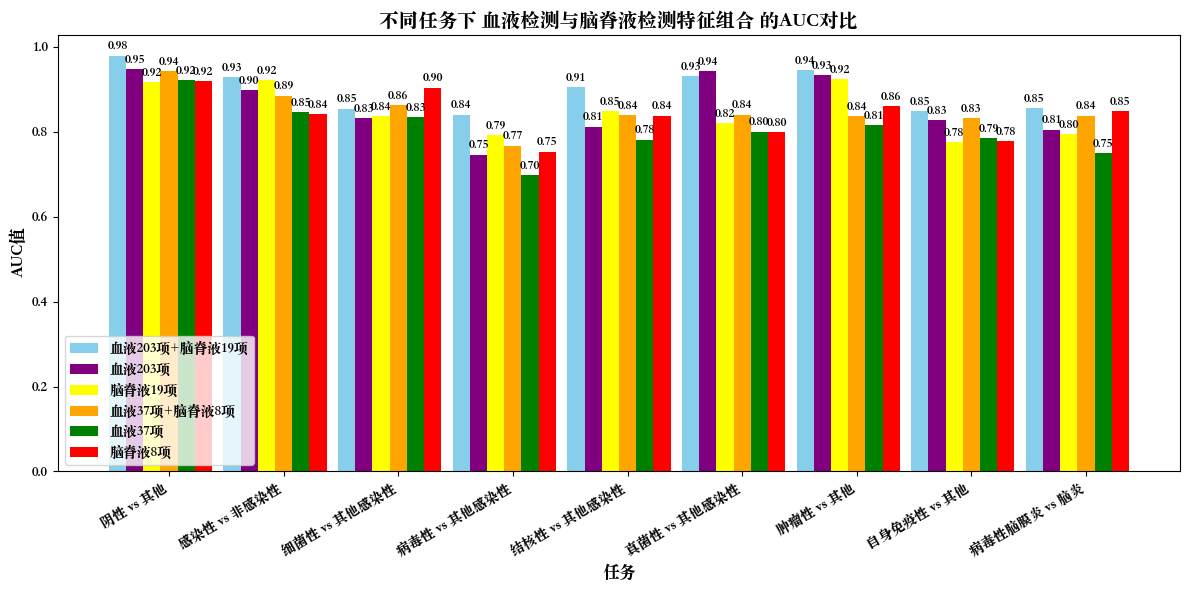

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
# df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

# singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/脑脊液与血液特征对比.xlsx", index_col='任务组')
model1 = list(df3['血液203项+脑脊液19项'])
model2 = list(df3['血液203项'])
model3 = list(df3['脑脊液19项'])
model4 = list(df3['血液37项+脑脊液8项'])
model5 = list(df3['血液37项'])
model6 = list(df3['脑脊液8项'])
# singel_model2 = [round(x*100,2) for x in singel_model2]
# singel_model3 = [round(x*100,2) for x in singel_model3]
# mixed_model1 = [round(x*100,2) for x in mixed_model1]
# mixed_model2 = [round(x*100,2) for x in mixed_model2]
# mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],

    "血液203项+脑脊液19项": model1,
    "血液203项": model2,
    "脑脊液19项": model3,
    "血液37项+脑脊液8项": model4,
    "血液37项": model5,
    "脑脊液8项": model6
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.15  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width*3, df["血液203项+脑脊液19项"], width, label="血液203项+脑脊液19项", color="skyblue")
bars2 = ax.bar(x - width*2, df["血液203项"], width, label="血液203项", color="purple")
bars3 = ax.bar(x - width, df["脑脊液19项"], width, label="脑脊液19项", color="yellow")
bars4 = ax.bar(x, df["血液37项+脑脊液8项"], width, label="血液37项+脑脊液8项", color="orange")
bars5 = ax.bar(x + width, df["血液37项"], width, label="血液37项", color="green")
bars6 = ax.bar(x + width*2, df["脑脊液8项"], width, label="脑脊液8项", color="red")

# 添加数值标签
for bar in bars1 + bars2 + bars3 + bars4 + bars5 + bars6:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 血液检测与脑脊液检测特征组合 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


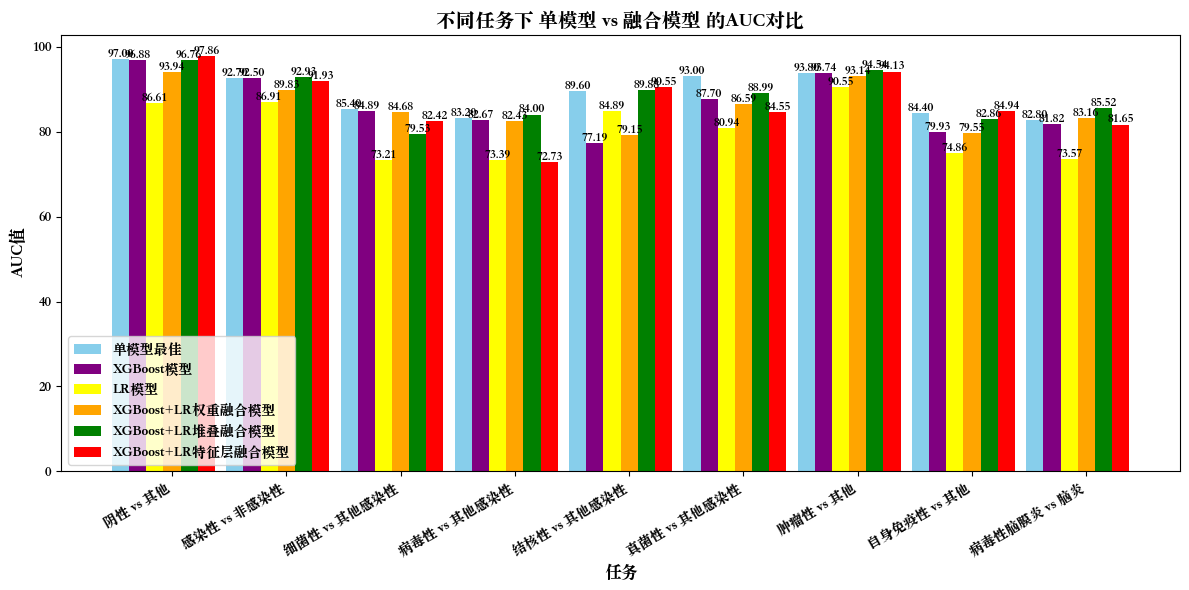

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)
singel_model2 = list(df3['XGboost模型结果']['血液203项+脑脊液19项'])
singel_model3 = list(df3['LR模型结果']['血液203项+脑脊液19项'])
mixed_model1 = list(df3['LR+XGBoost1模型结果']['血液203项+脑脊液19项'])
mixed_model2 = list(df3['LR+XGBoost2模型结果']['血液203项+脑脊液19项'])
mixed_model3 = list(df3['LR+XGBoost3模型结果']['血液203项+脑脊液19项'])
singel_model2 = [round(x*100,2) for x in singel_model2]
singel_model3 = [round(x*100,2) for x in singel_model3]
mixed_model1 = [round(x*100,2) for x in mixed_model1]
mixed_model2 = [round(x*100,2) for x in mixed_model2]
mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],
    "单模型最佳": singel_model,
    "XGBoost模型": singel_model2,
    "LR模型": singel_model3,
    "XGBoost+LR权重融合模型": mixed_model1,
    "XGBoost+LR堆叠融合模型": mixed_model2,
    "XGBoost+LR特征层融合模型": mixed_model3,
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.15  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width*3, df["单模型最佳"], width, label="单模型最佳", color="skyblue")
bars2 = ax.bar(x - width*2, df["XGBoost模型"], width, label="XGBoost模型", color="purple")
bars3 = ax.bar(x - width, df["LR模型"], width, label="LR模型", color="yellow")
bars4 = ax.bar(x, df["XGBoost+LR权重融合模型"], width, label="XGBoost+LR权重融合模型", color="orange")
bars5 = ax.bar(x + width, df["XGBoost+LR堆叠融合模型"], width, label="XGBoost+LR堆叠融合模型", color="green")
bars6 = ax.bar(x + width*2, df["XGBoost+LR特征层融合模型"], width, label="XGBoost+LR特征层融合模型", color="red")


# 添加数值标签
for bar in bars1 + bars2 + bars3 + bars4 + bars5 + bars6:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 单模型 vs 融合模型 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


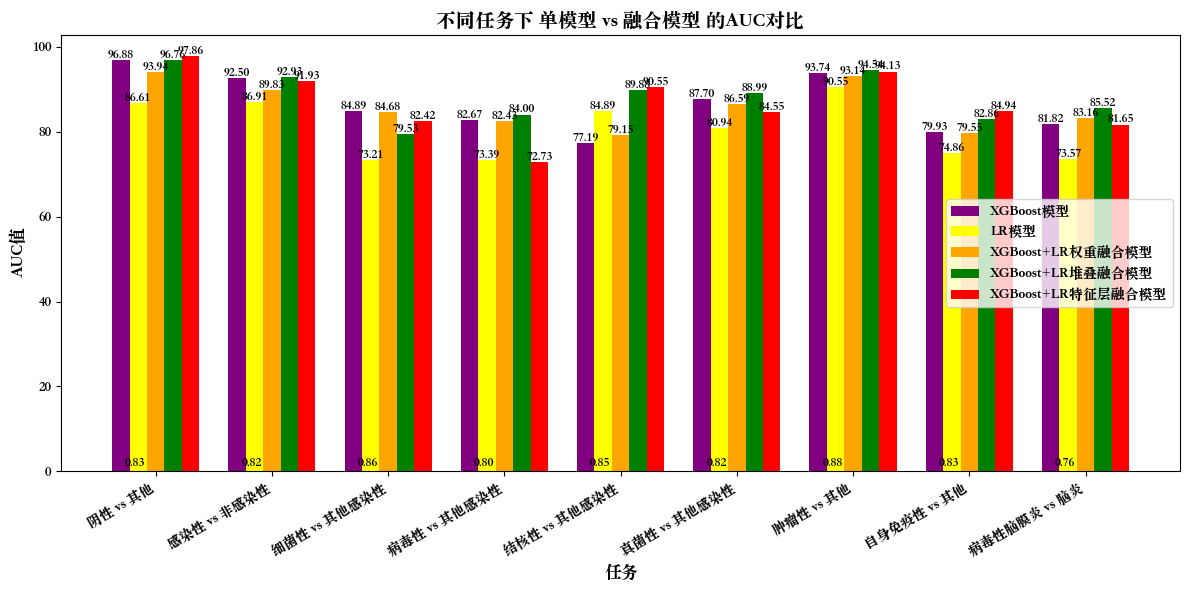

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

# singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)
singel_model2 = list(df3['XGBoost模型结果']['血液203项+脑脊液19项'])
singel_model3 = list(df3['LR模型结果']['血液203项+脑脊液19项'])
mixed_model1 = list(df3['LR+XGBoost1模型结果']['血液203项+脑脊液19项'])
mixed_model2 = list(df3['LR+XGBoost2模型结果']['血液203项+脑脊液19项'])
mixed_model3 = list(df3['LR+XGBoost3模型结果']['血液203项+脑脊液19项'])
singel_model2 = [round(x*100,2) for x in singel_model2]
singel_model3 = [round(x*100,2) for x in singel_model3]
mixed_model1 = [round(x*100,2) for x in mixed_model1]
mixed_model2 = [round(x*100,2) for x in mixed_model2]
mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],
    # "单模型最佳": singel_model,
    "XGBoost模型": singel_model2,
    "LR模型": singel_model3,
    "XGBoost+LR权重融合模型": mixed_model1,
    "XGBoost+LR堆叠融合模型": mixed_model2,
    "XGBoost+LR特征层融合模型": mixed_model3,
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.15  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
# bars1 = ax.bar(x - width*3, df["单模型最佳"], width, label="单模型最佳", color="skyblue")
bars2 = ax.bar(x - width*2, df["XGBoost模型"], width, label="XGBoost模型", color="purple")
bars3 = ax.bar(x - width, df["LR模型"], width, label="LR模型", color="yellow")
bars4 = ax.bar(x, df["XGBoost+LR权重融合模型"], width, label="XGBoost+LR权重融合模型", color="orange")
bars5 = ax.bar(x + width, df["XGBoost+LR堆叠融合模型"], width, label="XGBoost+LR堆叠融合模型", color="green")
bars6 = ax.bar(x + width*2, df["XGBoost+LR特征层融合模型"], width, label="XGBoost+LR特征层融合模型", color="red")


# 添加数值标签
for bar in bars1 + bars2 + bars3 + bars4 + bars5 + bars6:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 单模型 vs 融合模型 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


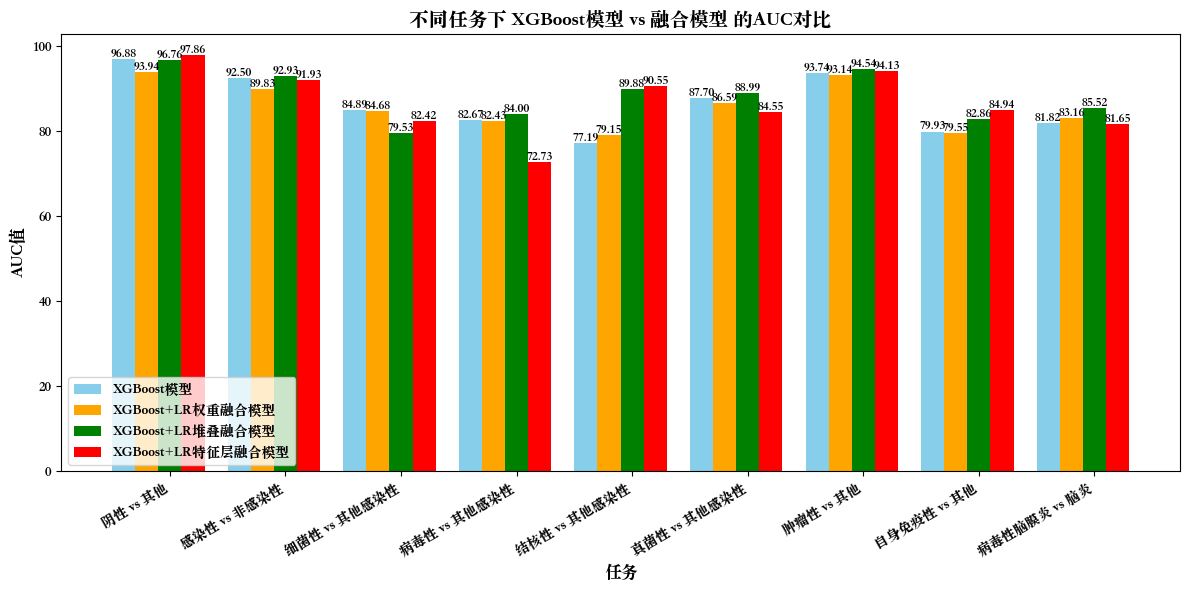

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)
singel_model = list(df3['XGBoost模型结果']['血液203项+脑脊液19项'])
mixed_model1 = list(df3['LR+XGBoost1模型结果']['血液203项+脑脊液19项'])
mixed_model2 = list(df3['LR+XGBoost2模型结果']['血液203项+脑脊液19项'])
mixed_model3 = list(df3['LR+XGBoost3模型结果']['血液203项+脑脊液19项'])
singel_model = [round(x*100,2) for x in singel_model]
mixed_model1 = [round(x*100,2) for x in mixed_model1]
mixed_model2 = [round(x*100,2) for x in mixed_model2]
mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],
    "XGBoost模型": singel_model,
    "XGBoost+LR权重融合模型": mixed_model1,
    "XGBoost+LR堆叠融合模型": mixed_model2,
    "XGBoost+LR特征层融合模型": mixed_model3,
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.2  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width*2, df["XGBoost模型"], width, label="XGBoost模型", color="skyblue")
bars2 = ax.bar(x - width, df["XGBoost+LR权重融合模型"], width, label="XGBoost+LR权重融合模型", color="orange")
bars3 = ax.bar(x, df["XGBoost+LR堆叠融合模型"], width, label="XGBoost+LR堆叠融合模型", color="green")
bars4 = ax.bar(x + width, df["XGBoost+LR特征层融合模型"], width, label="XGBoost+LR特征层融合模型", color="red")


# 添加数值标签
for bar in bars1 + bars2 + bars3 + bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 XGBoost模型 vs 融合模型 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


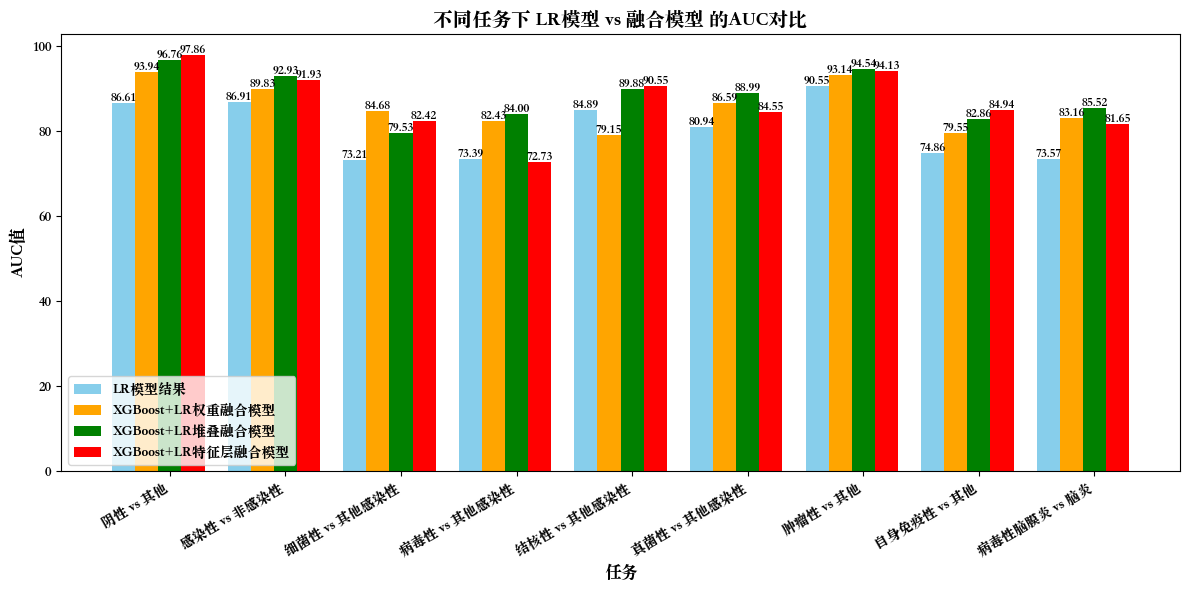

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 示例数据（任务 vs 单模型最佳AUC vs 融合模型AUC）
df2 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/单模型最优结果对比.xlsx")

singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)
singel_model = list(df3['LR模型结果']['血液203项+脑脊液19项'])
mixed_model1 = list(df3['LR+XGBoost1模型结果']['血液203项+脑脊液19项'])
mixed_model2 = list(df3['LR+XGBoost2模型结果']['血液203项+脑脊液19项'])
mixed_model3 = list(df3['LR+XGBoost3模型结果']['血液203项+脑脊液19项'])
singel_model = [round(x*100,2) for x in singel_model]
mixed_model1 = [round(x*100,2) for x in mixed_model1]
mixed_model2 = [round(x*100,2) for x in mixed_model2]
mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性 vs 其他", 
        "感染性 vs 非感染性", 
        "细菌性 vs 其他感染性", 
        "病毒性 vs 其他感染性",
        "结核性 vs 其他感染性", 
        "真菌性 vs 其他感染性", 
        "肿瘤性 vs 其他", 
        "自身免疫性 vs 其他", 
        "病毒性脑膜炎 vs 脑炎"
    ],
    "LR模型结果": singel_model,
    "XGBoost+LR权重融合模型": mixed_model1,
    "XGBoost+LR堆叠融合模型": mixed_model2,
    "XGBoost+LR特征层融合模型": mixed_model3,
}

df = pd.DataFrame(data)

# 设置柱子位置
x = np.arange(len(df["任务"]))  # 任务数
width = 0.2  # 每个柱子的宽度

# 绘制图形
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width*2, df["LR模型结果"], width, label="LR模型结果", color="skyblue")
bars2 = ax.bar(x - width, df["XGBoost+LR权重融合模型"], width, label="XGBoost+LR权重融合模型", color="orange")
bars3 = ax.bar(x, df["XGBoost+LR堆叠融合模型"], width, label="XGBoost+LR堆叠融合模型", color="green")
bars4 = ax.bar(x + width, df["XGBoost+LR特征层融合模型"], width, label="XGBoost+LR特征层融合模型", color="red")


# 添加数值标签
for bar in bars1 + bars2 + bars3 + bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
            ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)
    # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", 
    #         ha='center', va='bottom', fontsize=9)

# 设置标签和标题
ax.set_ylabel("AUC值", fontsize=12)
ax.set_xlabel("任务", fontsize=12)
ax.set_title("不同任务下 LR模型 vs 融合模型 的AUC对比", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["任务"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


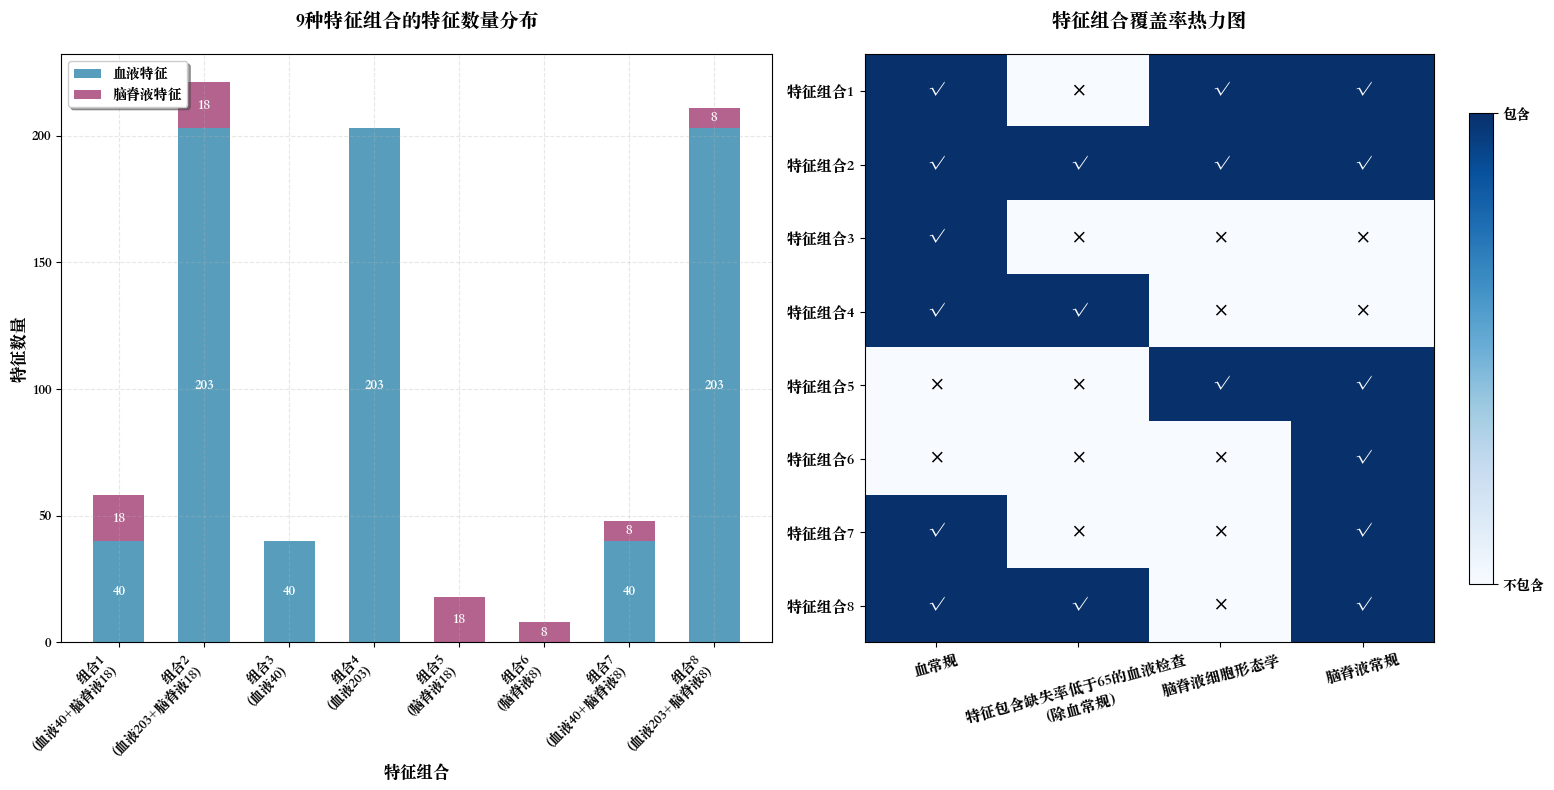

特征组合对比图已生成


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import pandas as pd

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建特征组合数据
feature_combinations = {
    '组合1\n(血液40+脑脊液18)': {'血液': 40, '脑脊液': 18, '总计': 58},
    '组合2\n(血液203+脑脊液18)': {'血液': 203, '脑脊液': 18, '总计': 221},
    '组合3\n(血液40)': {'血液': 40, '脑脊液': 0, '总计': 40},
    '组合4\n(血液203)': {'血液': 203, '脑脊液': 0, '总计': 203},
    '组合5\n(脑脊液18)': {'血液': 0, '脑脊液': 18, '总计': 18},
    '组合6\n(脑脊液8)': {'血液': 0, '脑脊液': 8, '总计': 8},
    '组合7\n(血液40+脑脊液8)': {'血液': 40, '脑脊液': 8, '总计': 48},
    '组合8\n(血液203+脑脊液8)': {'血液': 203, '脑脊液': 8, '总计': 211},
}

# 创建可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：特征数量堆叠柱状图
combinations = list(feature_combinations.keys())
blood_features = [feature_combinations[k]['血液'] for k in combinations]
csf_features = [feature_combinations[k]['脑脊液'] for k in combinations]

x_pos = np.arange(len(combinations))
width = 0.6

# 创建堆叠柱状图
bars1 = ax1.bar(x_pos, blood_features, width, label='血液特征', color='#2E86AB', alpha=0.8)
bars2 = ax1.bar(x_pos, csf_features, width, bottom=blood_features, label='脑脊液特征', color='#A23B72', alpha=0.8)

ax1.set_xlabel('特征组合', fontsize=12, fontweight='bold')
ax1.set_ylabel('特征数量', fontsize=12, fontweight='bold')
ax1.set_title('9种特征组合的特征数量分布', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(combinations, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')

# 添加数值标签
for i, (b, c) in enumerate(zip(blood_features, csf_features)):
    if b > 0:
        ax1.text(i, b/2, str(b), ha='center', va='center', fontweight='bold', color='white')
    if c > 0:
        ax1.text(i, b + c/2, str(c), ha='center', va='center', fontweight='bold', color='white')

# 右图：特征覆盖率热力图
coverage_data = []
feature_types = ['血常规', '特征包含缺失率低于65的血液检查\n（除血常规）', '脑脊液细胞形态学', '脑脊液常规']
combinations_simple = ['特征组合1', '特征组合2', '特征组合3', '特征组合4', '特征组合5', '特征组合6', '特征组合7', '特征组合8']

# 构建覆盖率矩阵
coverage_matrix = np.array([
    [1, 0, 1, 1],  # C1
    [1, 1, 1, 1],  # C2
    [1, 0, 0, 0],  # C3
    [1, 1, 0, 0],  # C4
    [0, 0, 1, 1],  # C5
    [0, 0, 0, 1],  # C6
    [1, 0, 0, 1],  # C7
    [1, 1, 0, 1],  # C8
])

im = ax2.imshow(coverage_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(feature_types)))
ax2.set_yticks(range(len(combinations_simple)))
ax2.set_xticklabels(feature_types, rotation=15, fontsize=11)
ax2.set_yticklabels(combinations_simple, fontsize=11)
ax2.set_title('特征组合覆盖率热力图', fontsize=14, fontweight='bold', pad=20)


# 添加文本标注
for i in range(len(combinations_simple)):
    for j in range(len(feature_types)):
        text = '√' if coverage_matrix[i, j] == 1 else '×'
        color = 'white' if coverage_matrix[i, j] == 1 else 'black'
        ax2.text(j, i, text, ha='center', va='center', color=color, fontweight='bold', fontsize=12)

# 添加颜色条
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['不包含', '包含'])

plt.tight_layout()
# plt.savefig('/mnt/okcomputer/output/feature_combinations_comparison.png', dpi=300, bbox_inches='tight', 
            # facecolor='white', edgecolor='none')
plt.show()

print("特征组合对比图已生成")

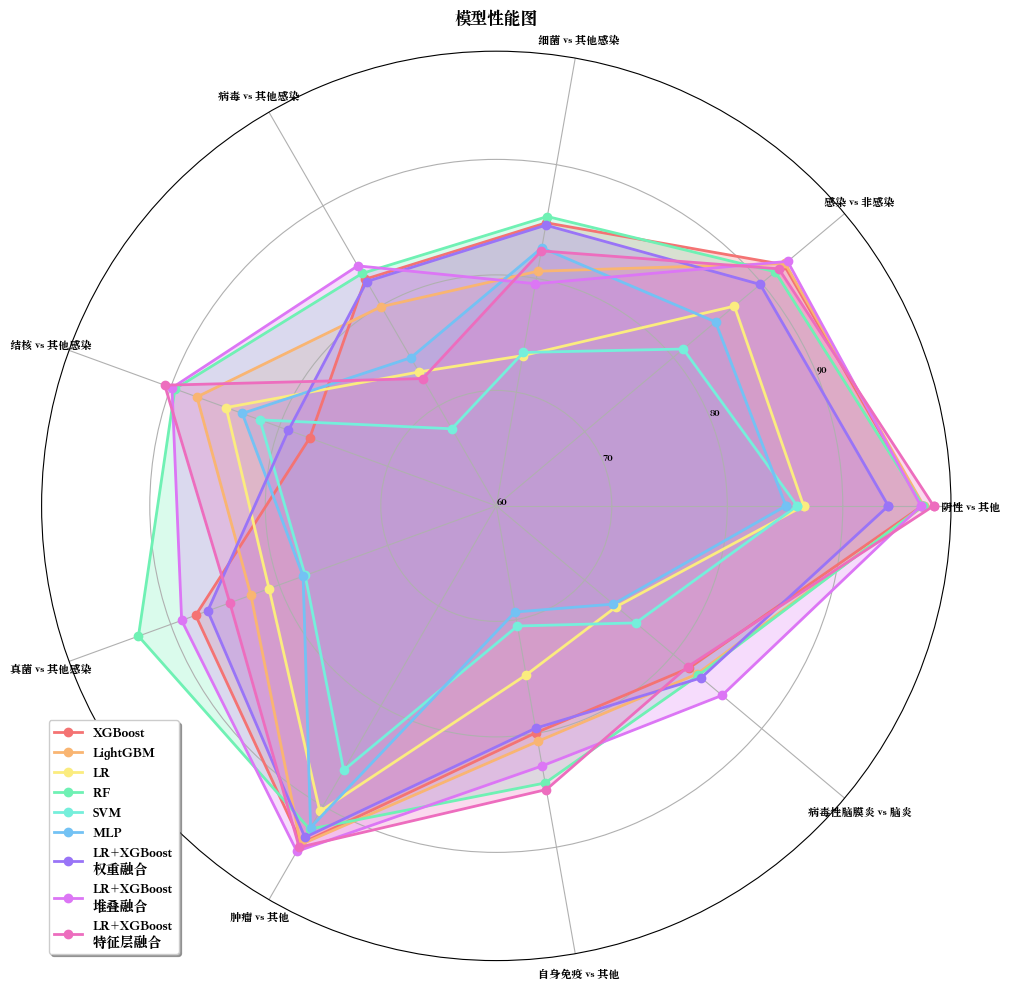

模型性能雷达图已生成


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from math import pi

# 模拟9个任务的模型性能数据（AUC值）
tasks = [
    '阴性vs其他', '感染vs非感染', '细菌vs其他感染', 
    '病毒vs其他感染', '结核vs其他感染', '真菌vs其他感染',
    '肿瘤vs其他', '自身免疫vs其他', '病毒性脑膜炎vs脑炎'
]

# 模拟10个模型的性能数据
models = ['XGBoost模型结果', 'LightGBM模型结果', 'LR模型结果', 'RF模型结果', 'SVM模型结果', 'MLP模型结果', 
          'LR+XGBoost1模型结果', 'LR+XGBoost2模型结果', 'LR+XGBoost3模型结果']

# 生成模拟性能数据（AUC值，范围0.5-1.0）
np.random.seed(42)
performance_data = {}

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)


for model in models:
    base_auc = list(df3[model]['血液203项+脑脊液19项'])
    base_auc = [round(x*100,2) for x in base_auc]
    performance_data[model] = base_auc

new_keys = {'XGBoost模型结果': 'XGBoost', 'LightGBM模型结果': 'LightGBM', 'LR模型结果': 'LR', 'RF模型结果':'RF', 'SVM模型结果': 'SVM', 'MLP模型结果': 'MLP', 
          'LR+XGBoost1模型结果': 'LR+XGBoost\n权重融合', 'LR+XGBoost2模型结果': 'LR+XGBoost\n堆叠融合', 'LR+XGBoost3模型结果': 'LR+XGBoost\n特征层融合'}

performance_data = {new_keys.get(k, k): v for k, v in performance_data.items()}
# [m.replace('XGBoost','XGBoost\n') for m in label]
# 创建雷达图
# fig, axes = plt.subplots(2, 5, figsize=(20, 10), subplot_kw=dict(projection='polar'))
# axes = axes.flatten()
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection='polar'))
# 颜色方案
# colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
# print(colors)
colors = ["#F47373FF", "#F9B572FF", "#FBEC7F", "#6FF1B4", "#75EFDB", "#73C2F4", "#9974F7", "#DC76F5FF", "#ED6DBE"]

for i, model in enumerate(list(performance_data.keys())):
    # ax = axes[i]
    
    # 获取数据
    values = performance_data[model]
    
    # 计算角度
    angles = [n / float(len(tasks)) * 2 * pi for n in range(len(tasks))]
    angles += angles[:1]  # 闭合图形
    
    # 添加数据并闭合
    values = np.concatenate((values, [values[0]]))
    
    # 绘制雷达图
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    # 设置标签
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([t.replace('vs', ' vs ') for t in tasks], fontsize=8)
    # ax.set_ylim(50, 100)
    ax.set_yticks([60, 70, 80, 90])
    ax.set_yticklabels(['60', '70', '80', '90'], fontsize=8)
    ax.grid(True)
    
    # 设置标题
plt.title('模型性能图', size=12, fontweight='bold', pad=20)
plt.legend(loc='lower left', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
# plt.savefig('/mnt/okcomputer/output/model_performance_radar.png', dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')
plt.show()

print("模型性能雷达图已生成")

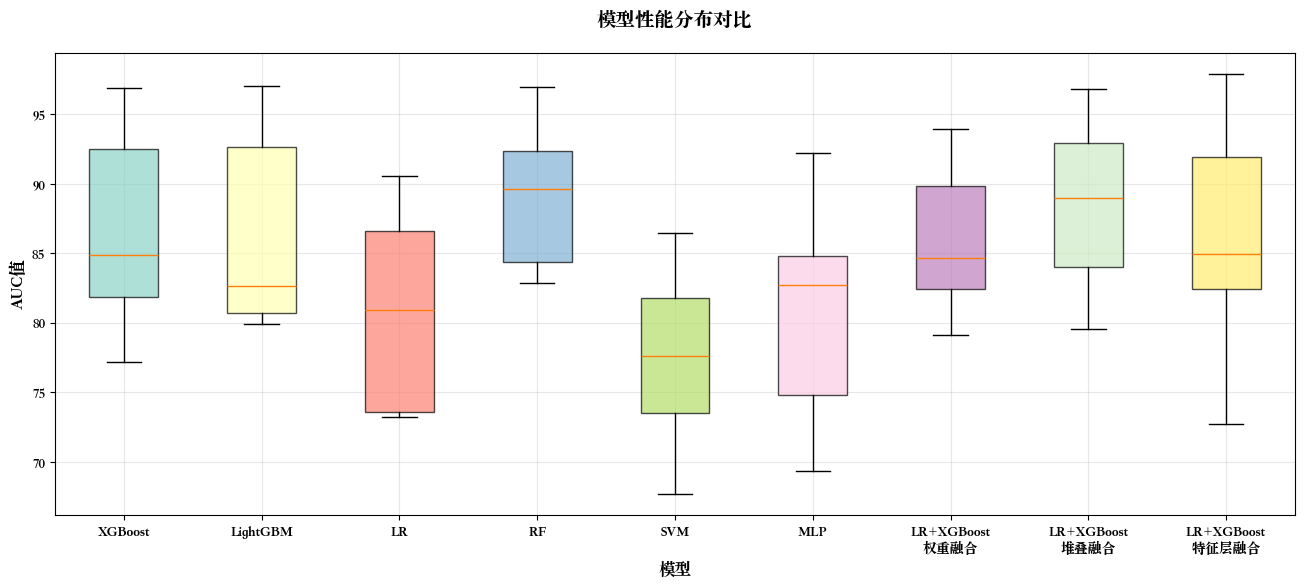

In [24]:
# 模拟10个模型的性能数据
models = ['XGBoost模型结果', 'LightGBM模型结果', 'LR模型结果', 'RF模型结果', 'SVM模型结果', 'MLP模型结果', 
          'LR+XGBoost1模型结果', 'LR+XGBoost2模型结果', 'LR+XGBoost3模型结果']

# 生成模拟性能数据（AUC值，范围0.5-1.0）
np.random.seed(42)
performance_data = []

df3 = pd.read_excel("/Users/yanjieni/Desktop/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)


for model in models:
    base_auc = list(df3[model]['血液203项+脑脊液19项'])
    base_auc = [round(x*100,2) for x in base_auc]
    performance_data.append(base_auc)

# new_keys = {'XGBoost模型结果': 'XGBoost', 'LightGBM模型结果': 'LightGBM', 'LR模型结果': 'LR', 'RF模型结果':'RF', 'SVM模型结果': 'SVM', 'HMM模型结果': 'HMM', 'MLP模型结果': 'MLP', 
#           'LR+XGBoost1模型结果': 'LR+XGBoost权重融合', 'LR+XGBoost2模型结果': 'LR+XGBoost堆叠融合', 'LR+XGBoost3模型结果': 'LR+XGBoost特征层融合'}

# performance_data = {new_keys.get(k, k): v for k, v in performance_data.items()}
label = ['XGBoost', 'LightGBM', 'LR', 'RF', 'SVM', 'MLP', 'LR+XGBoost权重融合', 'LR+XGBoost堆叠融合', 'LR+XGBoost特征层融合']

plt.figure(figsize=(16, 6))

box_plot = plt.boxplot(performance_data, tick_labels=[m.replace('XGBoost','XGBoost\n') for m in label], 
                      patch_artist=True)

colors_box = plt.cm.Set3(np.linspace(0, 1, len(models)))
for patch, color in zip(box_plot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xlabel('模型', fontsize=12, fontweight='bold')
plt.ylabel('AUC值', fontsize=12, fontweight='bold')
plt.title('模型性能分布对比', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
# plt.ylim(0.6, 1.0)
plt.show()